In [88]:
import cv2
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import json
from mmcv.transforms import Compose
import numpy as np
from mmdet.utils import get_test_pipeline_cfg

def read_json(json_path):
    with open(json_path) as f:
        data = json.load(f)
    return data

def preprocess(test_pipeline, image):
    if isinstance(image, np.ndarray):
        # Calling this method across libraries will result
        # in module unregistered error if not prefixed with mmdet.
        test_pipeline[0].type = 'mmdet.LoadImageFromNDArray'
    test_pipeline = Compose(test_pipeline)
    return test_pipeline(dict(img=image))

class CustomImageDataset(torch.utils.data.Dataset):
    def __init__(self, images_dir, annotations_json_path, transform=None):
        self.transform = transform
        self.images_dir = images_dir
        self.annotations_json = read_json(annotations_json_path)


    def __len__(self):
        return len(self.annotations_json['images'])

    def __getitem__(self, idx):
        image_dict = self.annotations_json['images'][idx]
        image_path = os.path.join(self.images_dir, image_dict['file_name'])
        image_id = image_dict['id']

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            transformed_images = self.transform(image)
        else:
            transformed_images = image

        return image_id, image_path, transformed_images


# calibrationDataloader = DataLoader(calibrationDataset, batch_size=32, shuffle=True)

In [89]:
# %cd /content/drive/MyDrive/Aimet-torch/mmdetection-3.3.0/
import torch
from mmdet.apis import DetInferencer

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize([640, 640]),  # Resize
])

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
CONFIG_PATH = 'rtmdet_tiny_8xb32-300e_coco.py'
WEIGHTS_PATH = '/teamspace/studios/this_studio/mmdetection/rtmdet_tiny_8xb32-300e_coco_20220902_112414-78e30dcc.pth'

ROOT_DATASET_DIR = '/teamspace/studios/aimet/COCO'
IMAGES_DIR = os.path.join(ROOT_DATASET_DIR, 'images')
ANNOTATIONS_JSON_PATH = os.path.join(ROOT_DATASET_DIR, 'annotations/instances_val2017.json')
# ANNOTATIONS_JSON_PATH = "/home/shayaan/Desktop/aimet/my_mmdet/temp.json"


model = DetInferencer(model=CONFIG_PATH, weights=WEIGHTS_PATH, device=DEVICE)
evalDataset = CustomImageDataset(images_dir=IMAGES_DIR, annotations_json_path=ANNOTATIONS_JSON_PATH, transform=transform)
DEVICE

Loads checkpoint by local backend from path: /teamspace/studios/this_studio/mmdetection/rtmdet_tiny_8xb32-300e_coco_20220902_112414-78e30dcc.pth


The model and loaded state dict do not match exactly

unexpected key in source state_dict: data_preprocessor.mean, data_preprocessor.std



/teamspace/studios/this_studio/mmengine/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


device(type='cpu')

backbone.stem.0.conv.weight


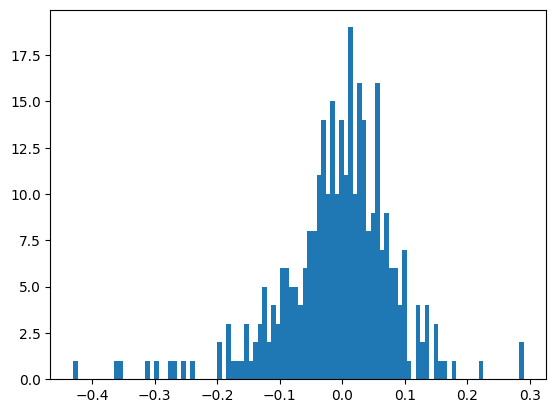

In [90]:
import matplotlib.pyplot as plt
name, values = list(model.model.named_parameters())[0]
values = values.flatten().detach().numpy()

plt.hist(values, bins=100)
print(name)

In [91]:
# quantized_path = "/teamspace/studios/this_studio/mmdetection/rtm_weights/gpu20aug_neck_range/rtm_det_gpu_20aug_20240820_100350_300/rtm_det.pth"
quantized_path = "/teamspace/studios/this_studio/mmdetection/A@tf/rtm_det.pth"
# quantized_path = "/teamspace/studios/this_studio/mmdetection/rtm_weights/gpu19aug/rtm_det_gpu_16Aug_rangelearning_20240819_155611_300/rtm_det.pth"
graph = torch.load(quantized_path, map_location="cpu")


backbone.stem.0.conv.weight


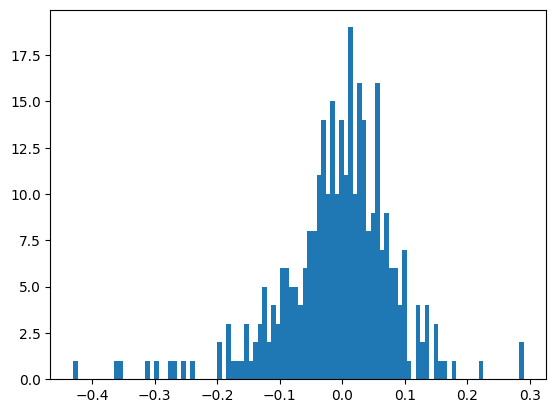

In [92]:
import matplotlib.pyplot as plt
values = dict(graph.named_parameters())[name]
values = values.flatten().detach().numpy()

plt.hist(values, bins=100)
print(name)